Problem Statement : Retailers like Walmart need accurate sales forecasts to plan inventory, staffing, and promotions. In this project, I aim to forecast weekly sales for a specific Walmart store based on historical sales trends. This helps store managers and corporate planners make informed decisions and avoid issues like stockouts or overstocking.

GOALS :
Finding → the predicted weekly sales for the next 52 weeks for Store 1 using historical data.

Evaluating → how well the model predicts sales using metrics like RMSE and MAPE.

Visualizing → trends, seasonality, and the confidence intervals of the predictions.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

In [9]:
df = pd.read_csv("Walmart_Sales.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [12]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")

# Sort values
df = df.sort_values('Date')

In [14]:
store_df = df[df['Store'] == 1].copy()
# Reset index
store_df.reset_index(drop=True, inplace=True)

In [16]:
print(f"Data shape for Store 1: {store_df.shape}")
print(store_df.head())


Data shape for Store 1: (143, 8)
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-02-05    1643690.90             0        42.31       2.572   
1      1 2010-02-12    1641957.44             1        38.51       2.548   
2      1 2010-02-19    1611968.17             0        39.93       2.514   
3      1 2010-02-26    1409727.59             0        46.63       2.561   
4      1 2010-03-05    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


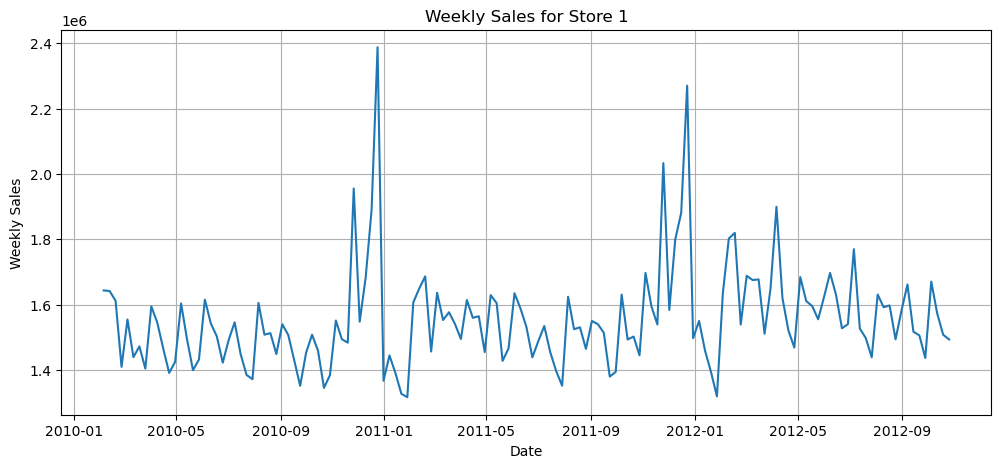

In [18]:
# 1. Time Series Plot
plt.figure(figsize=(12,5))
plt.plot(store_df['Date'], store_df['Weekly_Sales'])
plt.title('Weekly Sales for Store 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True)
plt.show()

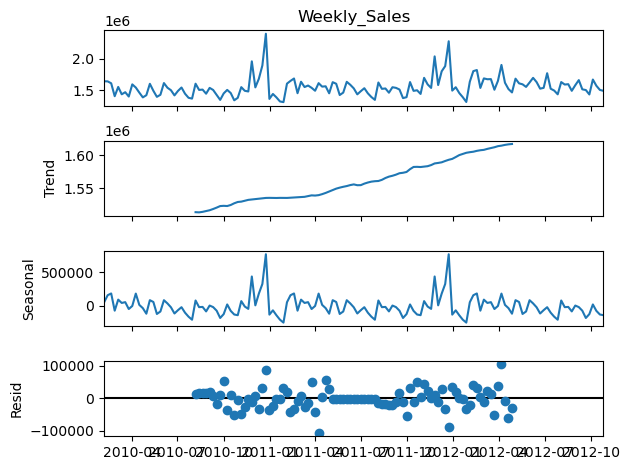

In [20]:
# 2. Seasonal Decomposition
store_df.set_index('Date', inplace=True)
decomp = seasonal_decompose(store_df['Weekly_Sales'], model='additive', period=52)
decomp.plot()
plt.show()

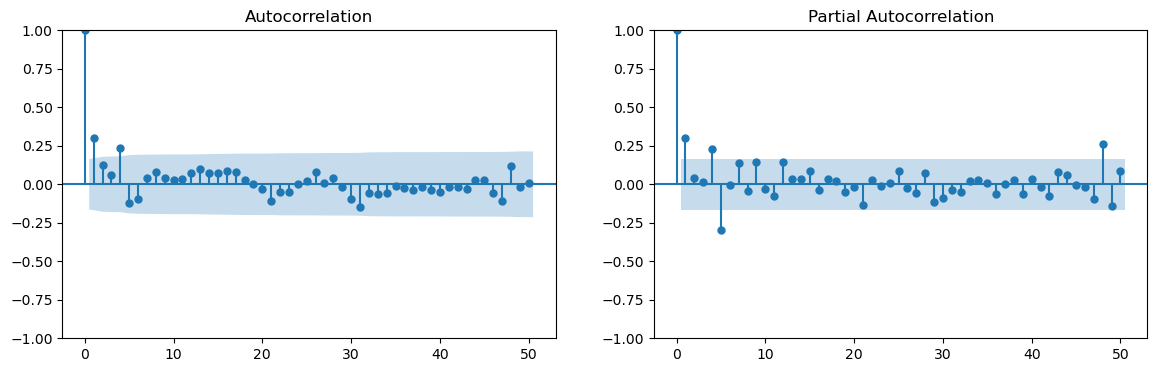

In [22]:
# 3. ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(store_df['Weekly_Sales'], ax=axes[0], lags=50)
plot_pacf(store_df['Weekly_Sales'], ax=axes[1], lags=50)
plt.show()

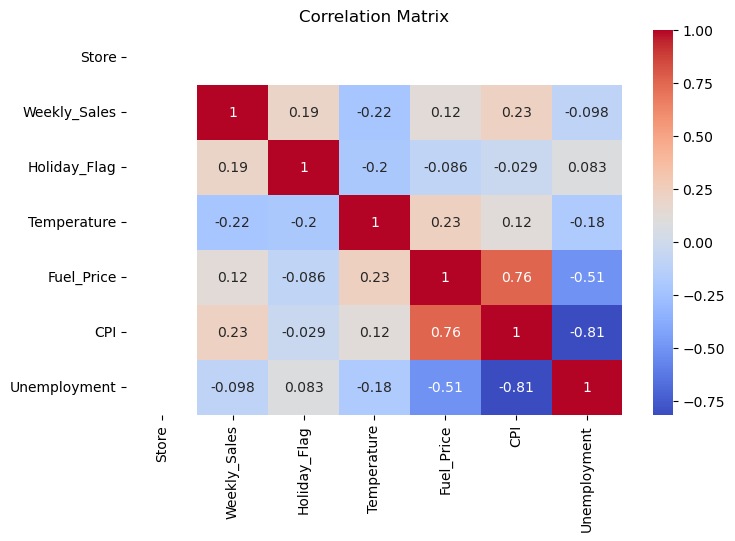

In [24]:
# 4. Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(store_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [26]:
train_size = int(len(store_df) * 0.85)
train = store_df.iloc[:train_size]
test = store_df.iloc[train_size:]

In [4]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(train['Weekly_Sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# If p-value > 0.05 → series is non-stationary → SARIMA handles this internally

NameError: name 'train' is not defined

In [31]:
# Step 4: SARIMA Model
# -----------------
# Example order & seasonal_order (can be tuned via AIC/BIC)
sarima_model = SARIMAX(train['Weekly_Sales'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,52),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

C:\Users\anuqu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\anuqu\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\anuqu\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  121
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -178.932
Date:                            Tue, 12 Aug 2025   AIC                            367.864
Time:                                    22:29:36   BIC                            371.060
Sample:                                02-05-2010   HQIC                           367.569
                                     - 05-25-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0847      0.364      0.233      0.816      -0.628       0.797
ma.L1         -1.0886      0.253   

In [33]:
# Step 5: Forecast
# -----------------
forecast = sarima_result.get_forecast(steps=len(test))
predictions = forecast.predicted_mean
conf_int = forecast.conf_int()


In [35]:
# Step 6: Evaluation
# -----------------
rmse = np.sqrt(mean_squared_error(test['Weekly_Sales'], predictions))
mape = mean_absolute_percentage_error(test['Weekly_Sales'], predictions) * 100

In [37]:
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

RMSE: 54678.86
MAPE: 2.64%


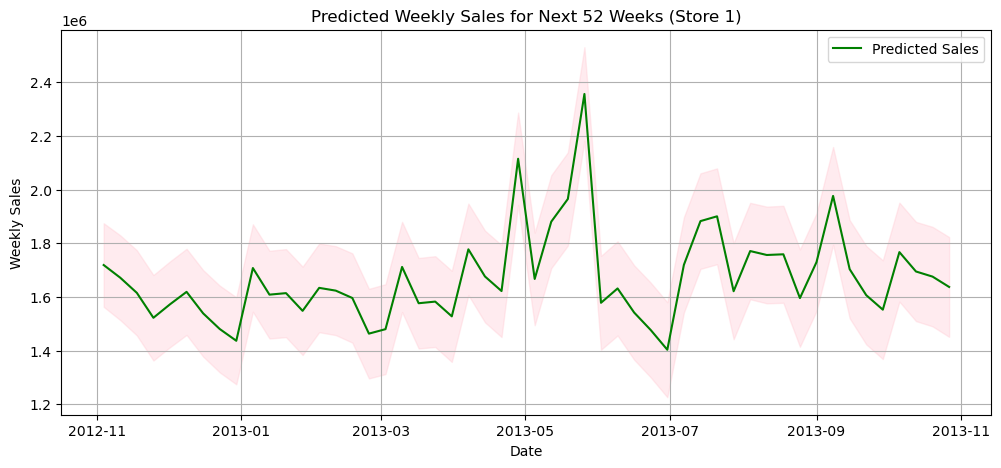

In [41]:
# Future forecast: next 52 weeks
future_forecast = sarima_result.get_forecast(steps=52)
future_pred = future_forecast.predicted_mean
future_conf_int = future_forecast.conf_int()

# Future dates
future_dates = pd.date_range(start=store_df.index[-1] + pd.Timedelta(weeks=1), 
                             periods=52, freq='W')

# Plot only forecast
plt.figure(figsize=(12,5))
plt.plot(future_dates, future_pred, label='Predicted Sales', color='green')
plt.fill_between(future_dates,
                 future_conf_int.iloc[:,0],
                 future_conf_int.iloc[:,1],
                 color='pink', alpha=0.3)

plt.title('Predicted Weekly Sales for Next 52 Weeks (Store 1)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.grid(True)
plt.show()


In [50]:
future_conf_int 

,lower Weekly_Sales,upper Weekly_Sales
2012-06-01,1.563048e+06,1.874773e+06
2012-06-08,1.513639e+06,1.829638e+06
2012-06-15,1.456494e+06,1.773892e+06
2012-06-22,1.362911e+06,1.681534e+06
2012-06-29,1.412491e+06,1.732320e+06
2012-07-06,1.458374e+06,1.779403e+06
2012-07-13,1.377636e+06,1.699861e+06
2012-07-20,1.318717e+06,1.642133e+06
2012-07-27,1.274184e+06,1.598788e+06
2012-08-03,1.544791e+06,1.870577e+06
